# Initial setups

mount google drive and authenticate to access files

In [ ]:
#connect to runtime GPU
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


check the currect directory content

In [ ]:
! ls
#%cd ML-CWs

 ADNI_Tadpole_data_tutorial.xlsx		    ML-TutorialsCW.ipynb
'Copy of ML-TutorialsCW.ipynb'			    Tutorial_3_data.csv
 Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


change directory to specific dir

In [ ]:
%cd gdrive/MyDrive/'Collaborate '

/content/gdrive/MyDrive/Collaborate 


install any package if missing

In [ ]:
#! pip install <desired-python-library>

check the access of any file

# Tutorial: 1-2

In [ ]:
# report writing

# Tutorial: 3

Load a CSV file into a list

In [ ]:
import csv

In [ ]:
filename = 'Tutorial_3_data.csv'
header = []
data = []

In [ ]:
csvfile = open(filename)
content_of_file = csv.reader(csvfile)

In [ ]:
header = next(content_of_file)
for row in content_of_file:
  data.append(row)

In [ ]:
csvfile.close()

Manipulation of data 

In [ ]:
print(len(data))
print(type(data))

2
<class 'list'>


In [ ]:
x = data[1]
y = data[0]
print(type(x))
print(type(y))

<class 'list'>
<class 'list'>


In [ ]:
valueofx = float(x[4])
valueofy = float(y[4])
print(valueofx)
print(valueofy)

dataofx = float(data[0][4])
dataofy = float(data[1][4])
print(type(dataofx))
print(type(dataofy))

print(valueofx * valueofy)
print(dataofx * dataofy)

0.00684158
-9.2
<class 'float'>
<class 'float'>
-0.062942536
-0.062942536


Plotting 

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
x = [float(i) for i in data[0]]
y = [float(i) for i in data[1]]

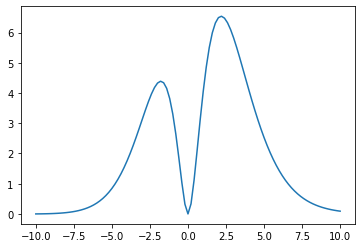

In [ ]:
plt.plot(x,y)

# Tutorial: 4

AdaBoost and KNN implementation

In [ ]:
import numpy as np
import csv

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

loading and manipulation of data

In [ ]:
filename = 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
data = []
header = []
label = []
csvfile = open(filename)
csvreader = csv.reader(csvfile)

In [ ]:
header = next(csvreader)
for row in csvreader:
  data.append(row[0:-2])
  if(row[-1] == 'BENIGN'):
    label.append(0)
  else:
    label.append(1)

data_mat = np.array(data)
label_mat = np.array(label)
csvfile.close()

ADABoost implementation 

In [ ]:
clf = AdaBoostClassifier(n_estimators = 10, random_state = 0)
clf.fit(data_mat, label_mat)

AdaBoostClassifier(n_estimators=10, random_state=0)

In [ ]:
label_hat = clf.predict(data_mat)

p1 = precision_score(label_mat, label_hat)
R1 = recall_score(label_mat, label_hat)
F1 = f1_score(label_mat, label_hat)

print(p1, R1, F1)

0.9990779953430952 0.9987268310590734 0.998902382338121


KNN implementation 

In [ ]:
knnClf = KNeighborsClassifier(n_neighbors=5)
knnClf.fit(data_mat, label_mat)
knn_Label_hat = knnClf.predict(data_mat)

/usr/local/lib/python3.8/dist-packages/sklearn/utils/validation.py:964: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(X, **check_params)


In [ ]:
knn_p1 = precision_score(label_mat, knn_Label_hat)
knn_R1 = recall_score(label_mat, label_hat)
knn_F1 = f1_score(label_mat, label_hat)
print(knn_p1,knn_R1, knn_F1)

0.9982752969454807 0.9987268310590734 0.998902382338121


In [ ]:
Pr=np.array([])
Rc=np.array([])
F1=np.array([])
Acc=np.array([])

for n in range(20):
    clf = KNeighborsClassifier(n_neighbors=n+1)
    clf.fit(data_mat, label_mat)
    label_hat=clf.predict(data_mat)

    Pr = np.append(Pr,precision_score(label_mat,label_hat))
    Rc = np.append(Rc,recall_score(label_mat,label_hat))
    F1 = np.append(F1,f1_score(label_mat,label_hat))
    Acc = np.append(Acc,accuracy_score(label_mat,label_hat))

In [ ]:
plt.plot(np.arange(20)+1,Acc)
plt.xlabel('Number of neighbours')
plt.ylabel('Accuracy')

plt.show()

optimization with Adaboost

In [ ]:
#estimatorList = [1,10,20,30,50,70,100]
estimatorList = [1,10,20]
for count in estimatorList:
    clf = AdaBoostClassifier(n_estimators = count, random_state = 0)
    clf.fit(data_mat, label_mat)

    label_hat = clf.predict(data_mat)

    p1 = precision_score(label_mat, label_hat)
    R1 = recall_score(label_mat, label_hat)
    F1 = f1_score(label_mat, label_hat)

    print(count, p1, R1, F1)

1 0.8153495392336056 1.0 0.898283797816508
10 0.9990779953430952 0.9987268310590734 0.998902382338121
20 0.9998515833710885 0.9997812961328469 0.9998164385166669


optimization with KNN

In [ ]:
knn_p1 = np.array([])

#neighborList = [1,2,3,4,5,6,7,8,9,10]
neighborList = [1,2,3]
for i in neighborList:
    knnClf = KNeighborsClassifier(n_neighbors=i)
    knnClf.fit(data_mat, label_mat)
    knn_Label_hat = knnClf.predict(data_mat)
    knn_p1 = np.append(knn_p1, precision_score(label_mat, knn_Label_hat))


/usr/local/lib/python3.8/dist-packages/sklearn/utils/validation.py:964: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(X, **check_params)
/usr/local/lib/python3.8/dist-packages/sklearn/utils/validation.py:964: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check

[1.         1.         0.99896162]


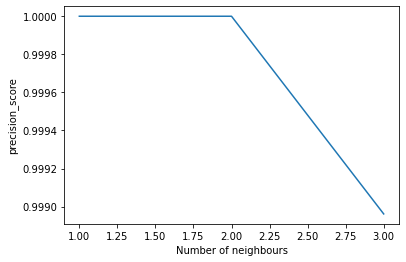

In [ ]:
print(knn_p1)
plt.plot(neighborList, knn_p1)
plt.xlabel('Number of neighbours')
plt.ylabel('precision_score')
plt.show()

# Tutorial: 5

K-Fold implementation

In [ ]:
import numpy as np
import csv

from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold, KFold

import matplotlib.pyplot as plt


In [ ]:
filename = 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
data = []
header = []
label = []
csvfile = open(filename)
csvreader = csv.reader(csvfile)

header = next(csvreader)
for row in csvreader:
  data.append(row[0:-2])
  if(row[-1] == 'BENIGN'):
    label.append(0)
  else:
    label.append(1)

data_mat = np.array(data)
label_mat = np.array(label)
csvfile.close()
print(data_mat.shape)

(225733, 77)


just to check how kfold works

In [ ]:
kf = KFold(n_splits = 10)
kf_split = kf.split(data_mat)
fold_index = next(kf_split)
print(kf_split)

<generator object _BaseKFold.split at 0x7f63bd1eca50>


In [ ]:
kf = KFold(n_splits = 10, shuffle = True)

Pr=np.zeros(10)
Rc=np.zeros(10)
F1=np.zeros(10)

for count, (train, test) in enumerate(kf.split(data_mat)):
  train_data = data_mat[train, :]
  train_label = label_mat[train]
  test_data = data_mat[test, :]
  test_label = label_mat[test]

  clf = AdaBoostClassifier(n_estimators = 1, random_state = 0)
  clf.fit(train_data, train_label)

  test_hat = clf.predict(test_data)

  Pr[count] = precision_score(test_label, test_hat)
  Rc[count] = recall_score(test_label, test_hat)
  F1[count] = f1_score(test_label, test_hat)

print(np.mean(Pr), np.std(Pr))

0.8153471267253394 0.0016105538911731542


 Mean Precision: 0.82 
 Standard deviation of Precision: 0.00


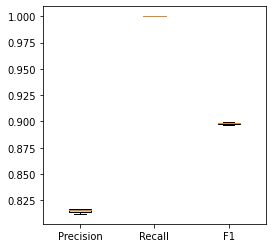

In [ ]:
#################################################################################################################
## Printing mean and standard deviation of the precision score
#################################################################################################################
Pr_mean=np.mean(Pr)
Pr_std=np.std(Pr)

print(' Mean Precision: {:.2f} \n Standard deviation of Precision: {:.2f}'.format(Pr_mean, Pr_std))


fig  = plt.figure(figsize=(4, 4))
bplot1 = plt.boxplot([Pr, Rc, F1],
                         vert=True,  # vertical box alignment
                         patch_artist=True,  # fill with color
                         labels=['Precision','Recall','F1'])  # will be used to label x-ticks

#################################################################################################################
## Plotting boxplots for the scores
#################################################################################################################

colors = ['lightblue', 'pink', 'lightgreen']
for patch, color in zip(bplot1['boxes'], colors):
    patch.set_facecolor(color)
        
plt.show()

In [ ]:
kf = StratifiedKFold(n_splits = 10, shuffle = True)

Pr=np.zeros(10)
Rc=np.zeros(10)
F1=np.zeros(10)
for count, (train, test) in enumerate(kf.split(data_mat, label_mat)):
  train_data = data_mat[train, :]
  train_label = label_mat[train]
  test_data = data_mat[test, :]
  test_label = label_mat[test]
  print("For next fold:", count)

  clf = AdaBoostClassifier(n_estimators = count+1, random_state = 0)
  clf.fit(train_data, train_label)

  test_hat = clf.predict(test_data)

  Pr[count] = precision_score(test_label, test_hat)
  Rc[count] = recall_score(test_label, test_hat)
  F1[count] = f1_score(test_label, test_hat)

print(count, np.mean(Pr), np.std(Pr))

For next fold: 0
For next fold: 1
For next fold: 2
For next fold: 3
For next fold: 4
For next fold: 5
For next fold: 6
For next fold: 7
For next fold: 8
For next fold: 9
9 0.980641250632367 0.055159587824007414


In [ ]:
kf = StratifiedKFold(n_splits = 10, shuffle = True)
Acc_mean=np.zeros(2)
for i in range(2):
    Pr_knn=np.zeros(10)
    Rc_knn=np.zeros(10)
    F1_knn=np.zeros(10)
    Acc_knn=np.zeros(10)

    for count, (train, test) in enumerate(kf.split(data_mat, label_mat)):
      train_data = data_mat[train, :]
      train_label = label_mat[train]
      test_data = data_mat[test, :]
      test_label = label_mat[test]

      print("For next fold:", count)
      knn_p1 = []

      knnClf = KNeighborsClassifier(n_neighbors=i+1)
      knnClf.fit(train_data, train_label)
      knn_Label_hat = knnClf.predict(test_data)

      knn_p1.append(precision_score(test_label, knn_Label_hat))
      Acc_knn[count] = accuracy_score(test_label, knn_Label_hat)
    Acc_mean = np.append(Acc_mean,np.mean(Acc_knn))


For next fold: 0


/usr/local/lib/python3.8/dist-packages/sklearn/utils/validation.py:964: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(X, **check_params)


For next fold: 1


/usr/local/lib/python3.8/dist-packages/sklearn/utils/validation.py:964: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(X, **check_params)


For next fold: 2


...

/usr/local/lib/python3.8/dist-packages/sklearn/utils/validation.py:964: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(X, **check_params)


For next fold: 8


/usr/local/lib/python3.8/dist-packages/sklearn/utils/validation.py:964: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(X, **check_params)


For next fold: 9


/usr/local/lib/python3.8/dist-packages/sklearn/utils/validation.py:964: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(
/usr/local/lib/python3.8/dist-packages/sklearn/base.py:566: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(X, **check_params)


[0.         0.         0.99863999 0.99848494]


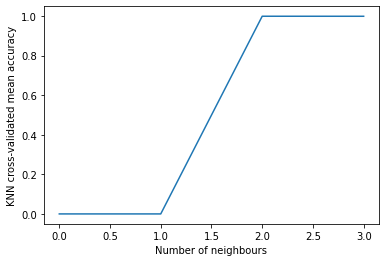

In [ ]:
print(Acc_mean)
plt.plot(np.arange(4), Acc_mean)
plt.xlabel('Number of neighbours')
plt.ylabel('KNN cross-validated mean accuracy')
plt.show()

# Tutorial: 6

In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [ ]:
filename = 'ADNI_Tadpole_data_tutorial.xlsx'
data_df = pd.read_excel(filename)
data_df.head()

y_target = data_df['Amyloid status']
x_data = data_df.drop(['PTID','SUVR','Amyloid status'], axis = 1)

In [ ]:
data_df.head()


,PTID,SUVR,Amyloid status,AGE,GENDER,EDUCATION,Diagnosis,ApoE4,CDRSB,ADAS11,...,Supramarginal gyrus left volume,Superior parietal Lobule right volume,Superior parietal Lobule left volume,Superior temporal gyrus right volume,Superior temporal gyrus left volume,Temporal pole right volume,Temporal pole left volume,Transverse temporal gyrus right volume,Transverse temporal gyrus left volume,Cerebrospinal fluid total volume
0,002_S_2010,1.14728,1,62.9,0,20,3,1,0.5,3.0,...,9547,11291,11409,12412,13006,1751,1915,886,1110,1149
1,002_S_2043,1.20402,1,72.2,0,20,3,1,0.5,2.0,...,10008,11898,11961,10394,11160,2289,2788,865,970,883
2,002_S_2073,1.18124,1,63.4,0,20,3,0,0.5,1.0,...,12367,13571,12420,11596,11616,2774,3271,937,1110,1548
3,002_S_4171,1.55195,1,69.4,1,16,2,0,0.5,1.5,...,8403,12811,12029,9351,9191,2030,1675,870,1058,1632
4,002_S_4219,1.04458,0,79.4,0,17,2,0,0.5,1.0,...,9268,11711,12264,9192,10030,1931,2189,966,1188,1354


logistic Regression

In [ ]:
clf = LogisticRegression()
clf.fit(x_data, y_target)

y_hat = clf.predict(x_data)


/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


confusion matrix and AUC

AUC: 0.6784
Accuracy: 0.7037


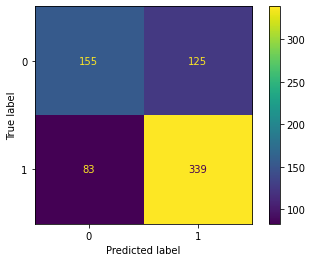

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score

print('AUC: {:.4f}'.format(roc_auc_score(y_target, y_hat)))
print('Accuracy: {:.4f}'.format(accuracy_score(y_target, y_hat>0.6)))

cm = confusion_matrix(y_target, y_hat>0.6)

disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot() 
plt.show()

In [ ]:
y_target = data_df['Amyloid status']
x_data = data_df[['AGE','GENDER','EDUCATION', 'ApoE4']]

In [ ]:
clf = LogisticRegression(penalty='none', class_weight='none', max_iter=10000, solver='saga' )
clf.fit(x_data, y_target)

y_hat = clf.predict(x_data)
y_prob = clf.predict_proba(x_data)

In [ ]:
print(clf.coef_, clf.intercept_)

[[ 0.03239256 -0.195827   -0.13584622  1.6954011 ]] [-0.43800734]


train test split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_target, train_size=0.75)

clf = LogisticRegression(penalty='none', class_weight='none', max_iter=10000, solver='saga' )
clf.fit(x_train, y_train)

y_hat = clf.predict(x_test)
y_prob = clf.predict_proba(x_test)

AUC: 0.7342
Accuracy: 0.7500


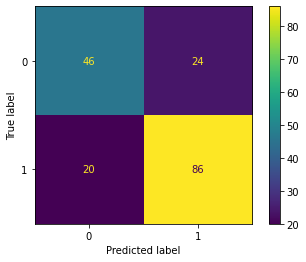

In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score

print('AUC: {:.4f}'.format(roc_auc_score(y_test, y_hat)))
print('Accuracy: {:.4f}'.format(accuracy_score(y_test, y_hat>0.6)))

cm = confusion_matrix(y_test, y_hat>0.6)

disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot() 
plt.show()

10 fold cross validation with logistic regression

In [ ]:
kf = KFold(n_splits = 10, shuffle = True)

auc=np.zeros(10)
acc=np.zeros(10)

data_mat = np.array(x_data)
label_mat = np.array(y_target)

for count, (train, test) in enumerate(kf.split(data_mat)):
  train_data = data_mat[train, :]
  train_label = label_mat[train]
  test_data = data_mat[test, :]
  test_label = label_mat[test]

  clf = LogisticRegression(penalty='none', class_weight='none', max_iter=10000, solver='saga' )
  clf.fit(train_data, train_label)

  y_hat = clf.predict(test_data)
  y_prob = clf.predict_proba(test_data)

  auc[count] = roc_auc_score(test_label, y_hat)
  acc[count] = accuracy_score(test_label, y_hat>0.6)
  print(count, auc[count], acc[count])


0 0.5640394088669951 0.5915492957746479
1 0.526578073089701 0.5774647887323944
2 0.6443108233117485 0.6714285714285714
3 0.5874999999999999 0.6142857142857143
4 0.6377777777777778 0.6714285714285714
5 0.6861888111888111 0.7142857142857143
6 0.6650326797385621 0.6571428571428571
7 0.666958041958042 0.7
8 0.6640033641715728 0.6714285714285714
9 0.6547619047619048 0.6714285714285714


In [ ]:
print(np.mean(auc), np.mean(acc))

0.6297150884865116 0.6540442655935614
